# Expected Goals from Scratch: Logistic Regression, and What Log Loss Does Not Measure

**31005 Machine Learning, A2 — Sean Woods (26107565), Spring 2026**

This notebook builds an expected goals (xG) model for football. Every part of the
learner is written by hand: the sigmoid, the log loss, the gradient, gradient
descent, and every evaluation metric. `scikit-learn` appears once, in a
verification cell, purely as a reference to check my arithmetic against.

## The task

Given one shot, output the probability that it becomes a goal.

**Training phase**
- Input: a matrix `X` of shape `(n, d)`, one row per historical shot, and a
  vector `y` in `{0,1}^n` where 1 means the shot was scored.
- Hyperparameters: learning rate, iteration budget, L2 strength, random seed.
- Output: a weight vector `w` in `R^(d+1)`, the bias sitting in `w[0]`.

**Deployment phase**
- Input: one shot's feature vector `x` in `R^d`, built with the same feature
  code and scaled with the *training* mean and standard deviation.
- Output: a single number in `[0, 1]`. Not a label. The probability is the
  product. Nobody wants a model that says "this shot is a goal"; they want to
  know that it was worth 0.31 of one.

## The research question

An xG model cannot know whether a particular shot goes in. Two identical
chances end differently and neither outcome is a mistake. What the model is
actually for is **calibration**: of all the chances it rates 0.30, close to 30%
should be scored. But it is trained by minimising **log loss on individual
binary outcomes**, which is not the same thing.

So: where does that gap bite, how do you detect it, and when you add features,
are you buying *calibration* (honesty) or *sharpness* (confidence)?


## 1. Setup

Only NumPy, pandas and matplotlib are needed to build and train the model.


In [1]:
import json, urllib.request
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RNG_SEED = 7
plt.rcParams.update({"figure.dpi": 120, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.25})
print("numpy", np.__version__, "| pandas", pd.__version__)


numpy 2.5.3 | pandas 3.0.6


## 2. Data

[StatsBomb Open Data](https://github.com/statsbomb/open-data): real event data,
free to use, recorded by human analysts. I take six men's senior international
tournaments, which keeps the population coherent (same level, same era, same
rules) rather than mixing men's and women's football or 1970s and 2020s matches.

Every shot in these competitions carries a **360 freeze frame**: the position of
every player visible at the moment the ball is struck. That is what lets me
count the defenders actually standing in the way, instead of guessing from the
shot location alone.

Penalties are removed. A penalty is the same shot every time, it is scored about
76% of the time, and leaving them in would let the model earn easy log loss for
recognising "the ball is on the spot" rather than learning anything about open
play.

The cell below downloads and parses roughly 314 matches. It takes a few minutes.


In [2]:
"""Pull shot events from the StatsBomb open data repo and write one flat CSV.

Population: men's senior international tournaments, 2018-2024.
Penalties are dropped (fixed situation, not a normal shot).
"""

BASE = "https://raw.githubusercontent.com/statsbomb/open-data/master/data"

COMPS = [
    (43, 3, "World Cup 2018"),
    (43, 106, "World Cup 2022"),
    (55, 43, "Euro 2020"),
    (55, 282, "Euro 2024"),
    (223, 282, "Copa America 2024"),
    (1267, 107, "AFCON 2023"),
]

FIELDS = [
    "match_id", "competition", "player", "team", "minute", "period",
    "x", "y", "body_part", "technique", "shot_type", "play_pattern",
    "first_time", "under_pressure", "open_goal", "follows_dribble",
    "n_opponents_in_frame", "defenders_in_cone", "keeper_x", "keeper_y",
    "assist_type", "assist_height",
    "statsbomb_xg", "outcome", "goal",
]


def fetch(url):
    with urllib.request.urlopen(url, timeout=60) as r:
        return json.load(r)


def pass_info(events):
    """id -> (pass type, pass height) so a shot can look up its assist."""
    out = {}
    for e in events:
        if e.get("type", {}).get("name") == "Pass":
            p = e["pass"]
            kind = p.get("type", {}).get("name", "Regular")
            if p.get("cross"):
                kind = "Cross"
            elif p.get("through_ball"):
                kind = "Through Ball"
            elif p.get("cut_back"):
                kind = "Cut Back"
            out[e["id"]] = (kind, p.get("height", {}).get("name", "Unknown"))
    return out


POST_A = (120.0, 36.0)
POST_B = (120.0, 44.0)


def in_triangle(p, a, b, c):
    """Point-in-triangle by the sign of three cross products."""
    def cross(u, v, w):
        return (v[0] - u[0]) * (w[1] - u[1]) - (v[1] - u[1]) * (w[0] - u[0])

    d1, d2, d3 = cross(p, a, b), cross(p, b, c), cross(p, c, a)
    has_neg = min(d1, d2, d3) < 0
    has_pos = max(d1, d2, d3) > 0
    return not (has_neg and has_pos)


def freeze_frame_counts(shot, loc):
    """Who is in the way: opponents in frame, defenders inside the shooting
    cone (the triangle from the ball to each post), and the keeper's position."""
    ff = shot.get("freeze_frame")
    if not ff:
        return "", "", "", ""
    opponents = [p for p in ff if not p["teammate"]]
    keeper = next(
        (p for p in ff if p.get("position", {}).get("name") == "Goalkeeper"
         and not p["teammate"]),
        None,
    )
    kx, ky = (keeper["location"] if keeper else ("", ""))
    in_cone = sum(
        1 for p in opponents
        if p is not keeper and in_triangle(p["location"], loc, POST_A, POST_B)
    )
    return len(opponents), in_cone, kx, ky


def shots_from_match(match):
    mid = match["match_id"]
    try:
        events = fetch(f"{BASE}/events/{mid}.json")
    except Exception as exc:  # a handful of matches time out
        print(f"  skipped {mid}: {exc}")
        return []

    passes = pass_info(events)
    rows = []
    for e in events:
        if e.get("type", {}).get("name") != "Shot":
            continue
        s = e["shot"]
        shot_type = s.get("type", {}).get("name", "")
        if shot_type == "Penalty":
            continue
        n_opp, in_cone, kx, ky = freeze_frame_counts(s, e["location"])
        assist = passes.get(s.get("key_pass_id"), ("None", "None"))
        outcome = s.get("outcome", {}).get("name", "")
        rows.append({
            "match_id": mid,
            "competition": match["_label"],
            "player": e.get("player", {}).get("name", ""),
            "team": e.get("team", {}).get("name", ""),
            "minute": e.get("minute", ""),
            "period": e.get("period", ""),
            "x": e["location"][0],
            "y": e["location"][1],
            "body_part": s.get("body_part", {}).get("name", ""),
            "technique": s.get("technique", {}).get("name", ""),
            "shot_type": shot_type,
            "play_pattern": e.get("play_pattern", {}).get("name", ""),
            "first_time": int(bool(s.get("first_time"))),
            "under_pressure": int(bool(e.get("under_pressure"))),
            "open_goal": int(bool(s.get("open_goal"))),
            "follows_dribble": int(bool(s.get("follows_dribble"))),
            "n_opponents_in_frame": n_opp,
            "defenders_in_cone": in_cone,
            "keeper_x": kx,
            "keeper_y": ky,
            "assist_type": assist[0],
            "assist_height": assist[1],
            "statsbomb_xg": s.get("statsbomb_xg", ""),
            "outcome": outcome,
            "goal": int(outcome == "Goal"),
        })
    return rows


def main(out_path):
    matches = []
    for comp_id, season_id, label in COMPS:
        got = fetch(f"{BASE}/matches/{comp_id}/{season_id}.json")
        for m in got:
            m["_label"] = label
        matches += got
        print(f"{label}: {len(got)} matches")

    print(f"downloading events for {len(matches)} matches ...")
    rows = []
    with ThreadPoolExecutor(max_workers=16) as pool:
        for batch in pool.map(shots_from_match, matches):
            rows += batch

    with open(out_path, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=FIELDS)
        w.writeheader()
        w.writerows(rows)

    goals = sum(r["goal"] for r in rows)
    print(f"{len(rows)} shots, {goals} goals ({goals / len(rows):.1%}) -> {out_path}")


In [3]:
def build_dataframe():
    matches = []
    for comp_id, season_id, label in COMPS:
        got = fetch(f"{BASE}/matches/{comp_id}/{season_id}.json")
        for m in got:
            m["_label"] = label
        matches += got
        print(f"{label}: {len(got)} matches")

    print(f"downloading events for {len(matches)} matches ...")
    rows = []
    with ThreadPoolExecutor(max_workers=16) as pool:
        for batch in pool.map(shots_from_match, matches):
            rows += batch
    return pd.DataFrame(rows, columns=FIELDS)


shots = build_dataframe()

# The extraction writes "" where a field is absent (two shots have no keeper in
# the freeze frame). Reading through a CSV would coerce those to NaN for free,
# but building the frame directly does not, so do it explicitly. Skipping this
# leaves object-dtype columns that blow up later in .to_numpy(float).
NUMERIC = ["minute", "period", "x", "y", "first_time", "under_pressure",
           "open_goal", "follows_dribble", "n_opponents_in_frame",
           "defenders_in_cone", "keeper_x", "keeper_y", "statsbomb_xg", "goal"]
for c in NUMERIC:
    shots[c] = pd.to_numeric(shots[c], errors="coerce")

shots = shots.dropna(subset=["x", "y", "goal"]).reset_index(drop=True)
print(f"\n{len(shots)} shots, {int(shots.goal.sum())} goals "
      f"({shots.goal.mean():.1%}), {shots.match_id.nunique()} matches")
shots.head()


World Cup 2018: 64 matches
World Cup 2022: 64 matches


Euro 2020: 51 matches


Euro 2024: 51 matches
Copa America 2024: 32 matches
AFCON 2023: 52 matches
downloading events for 314 matches ...


  skipped 3857282: <urlopen error _ssl.c:1063: The handshake operation timed out>


  skipped 3930164: <urlopen error _ssl.c:1063: The handshake operation timed out>


  skipped 3939972: <urlopen error _ssl.c:1063: The handshake operation timed out>


  skipped 3920403: <urlopen error _ssl.c:1063: The handshake operation timed out>

7414 shots, 658 goals (8.9%), 310 matches


,match_id,competition,player,team,minute,period,x,y,body_part,technique,...,follows_dribble,n_opponents_in_frame,defenders_in_cone,keeper_x,keeper_y,assist_type,assist_height,statsbomb_xg,outcome,goal
0,8650,World Cup 2018,Kevin De Bruyne,Belgium,1,1,91.0,51.0,Right Foot,Normal,...,0,8,0,118.0,41.0,None,None,0.020461,Off T,0
1,8650,World Cup 2018,Thiago Emiliano da Silva,Brazil,7,1,115.0,39.0,Right Foot,Normal,...,0,8,1,118.0,38.0,Cross,High Pass,0.274021,Post,0
2,8650,World Cup 2018,Eden Hazard,Belgium,7,1,106.0,31.0,Right Foot,Normal,...,0,8,3,119.0,39.0,Recovery,Ground Pass,0.065900,Blocked,0
3,8650,World Cup 2018,Nacer Chadli,Belgium,7,1,92.0,29.0,Right Foot,Normal,...,0,10,1,119.0,41.0,None,None,0.022908,Off T,0
4,8650,World Cup 2018,José Paulo Bezzera Maciel Júnior,Brazil,9,1,109.0,46.0,Right Foot,Normal,...,0,9,0,118.0,40.0,Regular,Ground Pass,0.174216,Blocked,0


In [4]:
# A first look at the class imbalance, which drives most of the decisions later.
print(shots.groupby("competition").goal.agg(["count", "mean"]).round(3))
print("\nbody part:\n", shots.body_part.value_counts())
print("\nbaseline: always predicting 'no goal' would be right "
      f"{1 - shots.goal.mean():.1%} of the time")


                   count   mean
competition                    
AFCON 2023          1128  0.082
Copa America 2024    718  0.084
Euro 2020           1234  0.099
Euro 2024           1278  0.076
World Cup 2018      1638  0.082
World Cup 2022      1418  0.106

body part:
 body_part
Right Foot    3752
Left Foot     2266
Head          1350
Other           46
Name: count, dtype: int64

baseline: always predicting 'no goal' would be right 91.1% of the time


## 3. Features

Two ideas do most of the work, and both are geometry.

**Distance** to the centre of the goal, and **angle**, the angle the goalmouth
subtends from where the ball is. Angle matters independently of distance: a shot
from the byline six yards out is close to the goal but can barely see any of it,
while the same distance straight on sees the whole face. Distance alone cannot
express that.

The angle is computed from the two posts. With `v1` and `v2` the vectors from
the ball to each post,

$$\theta = \arccos\left(\frac{v_1 \cdot v_2}{\|v_1\| \, \|v_2\|}\right)$$

Then three further blocks, added one at a time so the results table is a
controlled experiment rather than one big jump:

- **situation**: body part, first-time or not, under pressure, open goal, free
  kick, what kind of pass created it, what phase of play it came from
- **freeze frame**: defenders standing inside the triangle between the ball and
  the two posts, opponents in shot, how far the keeper is off his line and off
  his centre

Categorical variables are one-hot encoded with one level dropped, otherwise the
columns sum to a constant and the design matrix is rank deficient.


In [5]:
# StatsBomb pitch: 120 x 80, attacking goal at x = 120, posts at y = 36 and 44.
GOAL_CENTRE = np.array([120.0, 40.0])
POST_A = np.array([120.0, 36.0])
POST_B = np.array([120.0, 44.0])


# ----------------------------------------------------------------------------
# Features
# ----------------------------------------------------------------------------

def geometry(df):
    """Distance to the middle of the goal, and the angle the goalmouth
    subtends from the ball. A shot from the byline is close but has almost no
    angle, which is exactly why distance alone is not enough."""
    xy = df[["x", "y"]].to_numpy(float)
    dist = np.linalg.norm(xy - GOAL_CENTRE, axis=1)

    v1 = POST_A - xy
    v2 = POST_B - xy
    cos = (v1 * v2).sum(1) / (np.linalg.norm(v1, axis=1) * np.linalg.norm(v2, axis=1))
    angle = np.arccos(np.clip(cos, -1.0, 1.0))  # radians, 0 = no view of goal
    return dist, angle


CATEGORICALS = [("body_part", "Right Foot"),
                ("shot_type", "Open Play"),
                ("assist_type", "None"),
                ("play_pattern", "Regular Play")]


def category_levels(df):
    """Which levels each categorical can take. Taken from the training split
    and then reused, so every split produces the same columns in the same
    order. Letting each split name its own levels silently changes the model's
    input space, which is how I first got a shape mismatch."""
    return {col: sorted(df[col].dropna().unique()) for col, _ in CATEGORICALS}


def build_features(df, feature_set, levels=None):
    """Return a design matrix (no bias column yet) and the column names.

    Feature sets are nested on purpose: each one adds a block to the last, so
    the results table reads as a single controlled experiment.
    """
    levels = levels or category_levels(df)
    dist, angle = geometry(df)
    cols = {"distance": dist, "angle": angle}

    if feature_set == "distance":
        cols = {"distance": dist}

    elif feature_set in ("context", "full"):
        # Binary situation flags, already 0/1 in the CSV.
        for c in ["first_time", "under_pressure", "open_goal", "follows_dribble"]:
            cols[c] = df[c].to_numpy(float)
        # One-hot the categoricals. Drop one level of each to avoid a column
        # that is an exact sum of the others (the dummy variable trap).
        for col, drop in CATEGORICALS:
            for level in levels[col]:
                if level == drop:
                    continue
                key = f"{col}={level}".replace(" ", "_")
                cols[key] = (df[col] == level).to_numpy(float)

    if feature_set == "full":
        # 360 freeze-frame features: who is actually in the way.
        cols["defenders_in_cone"] = df["defenders_in_cone"].to_numpy(float)
        cols["n_opponents_in_frame"] = df["n_opponents_in_frame"].to_numpy(float)
        # How far off his line the keeper is, and how far he has drifted from
        # the middle of the goal. Two shots in 7451 have no keeper in the
        # frame at all, which is itself information (both were goals), so
        # rather than drop them I put the keeper on his line in the middle of
        # the goal and let a flag carry the fact that he was missing.
        keeper = df[["keeper_x", "keeper_y"]].to_numpy(float)
        missing = np.isnan(keeper[:, 0]) | np.isnan(keeper[:, 1])
        kx = np.where(missing, 120.0, keeper[:, 0])
        ky = np.where(missing, 40.0, keeper[:, 1])
        cols["keeper_off_line"] = 120.0 - kx
        cols["keeper_off_centre"] = np.abs(ky - 40.0)
        cols["keeper_not_in_frame"] = missing.astype(float)

    names = list(cols)
    X = np.column_stack([cols[n] for n in names])
    return X, names


class Standardiser:
    """z = (x - mean) / sd, with mean and sd learned from the training split
    only. Fitting these on all the data would leak test information into
    training, and gradient descent needs the scaling or the learning rate that
    suits 'distance' (0-100) is wildly wrong for a 0/1 flag."""

    def fit(self, X):
        self.mean_ = X.mean(0)
        self.sd_ = X.std(0)
        self.sd_[self.sd_ == 0] = 1.0  # constant column: leave it alone
        return self

    def transform(self, X):
        return (X - self.mean_) / self.sd_


## 4. The model

Three design choices, in the language of the subject.

**H — the hypothesis space.** Every function of the form

$$h_{w}(x) = \sigma(w^\top x + b), \qquad \sigma(z) = \frac{1}{1 + e^{-z}}$$

Choosing weights picks one member out of that infinite family. The sigmoid is
not decoration: it is what makes the output a probability, squashing any real
number into `(0, 1)` and never reaching either end, which matters because no
shot is ever truly impossible or certain.

**L — the criterion.** Binary cross-entropy, also called log loss:

$$L(w) = \frac{1}{n}\sum_{i=1}^{n} -\big[y_i \log p_i + (1-y_i)\log(1-p_i)\big] + \lambda\|w\|^2$$

Two reasons for it over squared error. First, it is a *proper scoring rule*: it
is minimised, in expectation, exactly when the predicted probability equals the
true probability, which is precisely what an xG model is supposed to produce.
Second, its gradient does not vanish when the model is confidently wrong. I test
that claim in section 9 by training the same model on squared error instead.

**A — the algorithm.** Full-batch gradient descent. With the bias folded into
the design matrix as a column of ones,

$$\nabla L = \frac{1}{n} X^\top (\sigma(Xw) - y) + 2\lambda w$$

The derivation is worth doing once, because the sigmoid's derivative and the
log's derivative cancel:

$$\frac{\partial}{\partial w_j} \Big[-y\log\sigma(z) - (1-y)\log(1-\sigma(z))\Big]
= (\sigma(z) - y)\,x_j$$

The whole gradient is "how wrong you were, times the input". 7,451 shots is
small, so full batch is fine and the loss curve comes out smooth, with no
mini-batch noise to explain away.


In [6]:
def sigmoid(z):
    """1 / (1 + e^-z), written so a large negative z cannot overflow."""
    out = np.empty_like(z, dtype=float)
    pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[~pos])
    out[~pos] = ez / (1.0 + ez)
    return out


class LogisticRegressionGD:
    """H : x -> sigmoid(w . x + b), every w and b being one hypothesis.
    L : mean binary cross-entropy + L2 penalty on w (not on b).
    A : full-batch gradient descent.
    """

    def __init__(self, lr=0.5, n_iter=4000, l2=0.0, tol=1e-9, seed=0):
        self.lr = lr
        self.n_iter = n_iter
        self.l2 = l2
        self.tol = tol
        self.seed = seed

    def _add_bias(self, X):
        return np.column_stack([np.ones(len(X)), X])

    def loss(self, Xb, y, w):
        """Mean cross-entropy computed through logaddexp, which is the stable
        way to write -[y log p + (1-y) log(1-p)]:
            -y*z + log(1 + e^z)  =  -y*z + logaddexp(0, z)
        """
        z = Xb @ w
        ce = np.mean(-y * z + np.logaddexp(0.0, z))
        return ce + self.l2 * np.sum(w[1:] ** 2)

    def gradient(self, Xb, y, w):
        """d/dw of the loss above. The sigmoid and the log cancel, which is why
        this comes out as plain 'error times input'."""
        p = sigmoid(Xb @ w)
        g = Xb.T @ (p - y) / len(y)
        reg = 2.0 * self.l2 * w
        reg[0] = 0.0  # never penalise the bias: it sets the base goal rate
        return g + reg

    def fit(self, X, y, X_val=None, y_val=None, track_every=25):
        Xb = self._add_bias(X)
        rng = np.random.default_rng(self.seed)
        w = rng.normal(0, 0.01, Xb.shape[1])
        self.history_ = []
        prev = np.inf

        for i in range(self.n_iter):
            w -= self.lr * self.gradient(Xb, y, w)
            if i % track_every == 0 or i == self.n_iter - 1:
                tr = self.loss(Xb, y, w)
                va = (self.loss(self._add_bias(X_val), y_val, w)
                      if X_val is not None else np.nan)
                self.history_.append((i, tr, va))
                if abs(prev - tr) < self.tol:
                    break
                prev = tr

        self.w_ = w
        self.n_iter_run_ = i + 1
        return self

    def predict_proba(self, X):
        return sigmoid(self._add_bias(X) @ self.w_)


### 4b. Does the gradient actually match the loss?

A hand-derived gradient is the easiest thing in this project to get quietly
wrong, and a wrong gradient still trains, just badly. Central differences give
an independent check:

$$\frac{\partial L}{\partial w_j} \approx \frac{L(w + he_j) - L(w - he_j)}{2h}$$

Agreement to around 1e-10 means the calculus and the code say the same thing.


In [7]:
def check_gradient():
    rng = np.random.default_rng(0)
    X = rng.normal(size=(60, 4))
    y = (rng.random(60) < 0.3).astype(float)
    m = LogisticRegressionGD(l2=0.05)
    Xb = m._add_bias(X)
    w = rng.normal(0, 0.5, Xb.shape[1])

    analytic = m.gradient(Xb, y, w)
    numeric = np.zeros_like(w)
    h = 1e-6
    for i in range(len(w)):
        wp, wm = w.copy(), w.copy()
        wp[i] += h
        wm[i] -= h
        numeric[i] = (m.loss(Xb, y, wp) - m.loss(Xb, y, wm)) / (2 * h)

    rel = np.abs(analytic - numeric).max() / np.abs(numeric).max()
    print(f"max relative error between analytic and numerical gradient: {rel:.2e}")
    assert rel < 1e-6
    return rel


check_gradient()


max relative error between analytic and numerical gradient: 4.55e-10


np.float64(4.545717559627697e-10)

## 5. Validation scheme: split by match, never by shot

Shots from the same match share a goalkeeper, a pitch, a scoreline and a
defensive shape. They are not independent draws from the population. If some
shots from a match sit in training and others in test, the test set is no longer
fresh, and the generalisation estimate it gives is optimistic. So whole matches
move together.

- **Train** 60% of matches, used to fit weights.
- **Validation** 20%, used to watch convergence and to sanity-check choices.
- **Test** 20%, touched once, at the end.

Hyperparameters are chosen by **5-fold cross-validation inside the training
matches**, again splitting by match. Reporting the standard deviation across
folds matters: a difference smaller than the fold-to-fold spread is noise, not a
result.


In [8]:
def split_by_match(df, fracs=(0.6, 0.2, 0.2), seed=7):
    """Two shots from the same match share a keeper, a pitch and a game state,
    so they are not independent draws. Splitting by shot would put near-copies
    on both sides of the fence and flatter the test score."""
    ids = np.array(sorted(df.match_id.unique()))
    rng = np.random.default_rng(seed)
    rng.shuffle(ids)
    n_tr = int(fracs[0] * len(ids))
    n_va = int(fracs[1] * len(ids))
    groups = {"train": ids[:n_tr], "val": ids[n_tr:n_tr + n_va], "test": ids[n_tr + n_va:]}
    return {k: df[df.match_id.isin(v)].reset_index(drop=True) for k, v in groups.items()}


def match_folds(df, k=5, seed=7):
    """k-fold cross-validation where whole matches move between folds."""
    ids = np.array(sorted(df.match_id.unique()))
    rng = np.random.default_rng(seed)
    rng.shuffle(ids)
    for fold in np.array_split(ids, k):
        held = df.match_id.isin(fold)
        yield df[~held].reset_index(drop=True), df[held].reset_index(drop=True)


In [9]:
shots["goal"] = shots.goal.astype(float)
parts = split_by_match(shots, seed=RNG_SEED)
tr, va, te = parts["train"], parts["val"], parts["test"]
y_tr, y_va, y_te = (p.goal.to_numpy(float) for p in (tr, va, te))

print(f"shots    train {len(tr):5d}   val {len(va):5d}   test {len(te):5d}")
print(f"matches  train {tr.match_id.nunique():5d}   val {va.match_id.nunique():5d}"
      f"   test {te.match_id.nunique():5d}")
print(f"goal rate train {y_tr.mean():.3f}   val {y_va.mean():.3f}   test {y_te.mean():.3f}")
assert not set(tr.match_id) & set(te.match_id), "match appears in two splits"


shots    train  4430   val  1566   test  1418
matches  train   186   val    62   test    62
goal rate train 0.092   val 0.076   test 0.094


## 6. Metrics, written out

Each one answers a different question, and one of them answers none.

| Metric | Question it answers |
|---|---|
| **Log loss** | How surprised was the model by what happened? The training criterion. |
| **Brier score** | Mean squared error of the probabilities. Decomposes usefully. |
| **Reliability** | Are the stated probabilities honest? Lower is better, 0 is perfect. |
| **Resolution** | Does the model separate good chances from bad? Higher is better. |
| **ECE** | Average size of the calibration miss, in probability points. |
| **ROC-AUC** | Chance a random goal is rated above a random miss. Ranking only. |
| **Average precision** | Same idea, but sensitive to the rare positive class. |
| **Accuracy** | Nothing useful here. Shown to prove it. |

Murphy's decomposition is the one that answers the research question directly:

$$\text{Brier} = \underbrace{\text{reliability}}_{\text{honesty}} - \underbrace{\text{resolution}}_{\text{sharpness}} + \underbrace{\text{uncertainty}}_{\text{fixed by the data}}$$


In [10]:
def log_loss(y, p, eps=1e-15):
    p = np.clip(p, eps, 1 - eps)
    return float(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)))


def brier(y, p):
    return float(np.mean((p - y) ** 2))


def accuracy(y, p, threshold=0.5):
    return float(np.mean((p >= threshold) == y))


def roc_auc(y, p):
    """Rank version of the Mann-Whitney statistic: the chance a random goal is
    scored higher than a random non-goal. Ties share the average rank."""
    order = np.argsort(p, kind="mergesort")
    ranks = np.empty(len(p), float)
    sorted_p = p[order]
    i = 0
    while i < len(p):
        j = i
        while j + 1 < len(p) and sorted_p[j + 1] == sorted_p[i]:
            j += 1
        ranks[order[i:j + 1]] = 0.5 * (i + j) + 1.0
        i = j + 1
    n_pos = y.sum()
    n_neg = len(y) - n_pos
    return float((ranks[y == 1].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg))


def average_precision(y, p):
    """Area under precision-recall, as the step-wise sum used by sklearn."""
    order = np.argsort(-p, kind="mergesort")
    y = y[order]
    tp = np.cumsum(y)
    precision = tp / np.arange(1, len(y) + 1)
    return float((precision * y).sum() / y.sum())


def calibration_table(y, p, bins=10, strategy="quantile"):
    """Bucket the predictions, then compare what was promised with what
    happened. This is the table the whole project argues about."""
    if strategy == "quantile":
        edges = np.unique(np.quantile(p, np.linspace(0, 1, bins + 1)))
    else:
        edges = np.linspace(0, 1, bins + 1)
    if len(edges) < 2:
        # A constant predictor (the base-rate baseline) has no quantiles to
        # cut on, so everything goes in a single bin.
        edges = np.array([p.min() - 1e-9, p.max() + 1e-9])
    idx = np.clip(np.digitize(p, edges[1:-1]), 0, len(edges) - 2)
    rows = []
    for b in range(len(edges) - 1):
        m = idx == b
        if m.sum() == 0:
            continue
        rows.append({
            "bin": b,
            "n": int(m.sum()),
            "mean_pred": float(p[m].mean()),
            "observed": float(y[m].mean()),
            "goals": int(y[m].sum()),
        })
    return pd.DataFrame(rows)


def brier_decomposition(y, p, bins=10):
    """Murphy's split: Brier = reliability - resolution + uncertainty.

    reliability  how far the promised rate sits from the observed rate (lower
                 is better, 0 means perfectly calibrated)
    resolution   how far the bins spread away from the base rate (higher is
                 better, it is sharpness that pays off)
    uncertainty  the base rate's own variance, fixed by the data, nothing the
                 model can do about it
    """
    t = calibration_table(y, p, bins=bins)
    n = len(y)
    base = y.mean()
    rel = float((t.n * (t.mean_pred - t.observed) ** 2).sum() / n)
    res = float((t.n * (t.observed - base) ** 2).sum() / n)
    unc = float(base * (1 - base))
    return {"reliability": rel, "resolution": res, "uncertainty": unc,
            "brier_check": rel - res + unc}


def expected_calibration_error(y, p, bins=10):
    t = calibration_table(y, p, bins=bins)
    return float((t.n * (t.mean_pred - t.observed).abs()).sum() / len(y))


def evaluate(y, p, bins=10):
    d = brier_decomposition(y, p, bins=bins)
    return {
        "log_loss": log_loss(y, p),
        "brier": brier(y, p),
        "ece": expected_calibration_error(y, p, bins=bins),
        "reliability": d["reliability"],
        "resolution": d["resolution"],
        "roc_auc": roc_auc(y, p),
        "avg_precision": average_precision(y, p),
        "accuracy": accuracy(y, p),
        "mean_pred": float(p.mean()),
        "base_rate": float(y.mean()),
    }


In [11]:
def prepare(train_df, other_dfs, feature_set):
    """Build features for train, fit the scaler on train, apply it elsewhere."""
    levels = category_levels(train_df)
    X_tr, names = build_features(train_df, feature_set, levels)
    sc = Standardiser().fit(X_tr)
    out = [sc.transform(X_tr)]
    for d in other_dfs:
        X, _ = build_features(d, feature_set, levels)
        out.append(sc.transform(X))
    return out, names, sc


### 6b. Checking the metrics against a reference

This is the only cell in the notebook that imports scikit-learn, and it does not
touch the model. It exists so that "I wrote my own log loss" is a verified claim
rather than a hopeful one.


In [12]:
from sklearn.metrics import (average_precision_score, brier_score_loss,
                             log_loss as sk_log_loss, roc_auc_score)

rng = np.random.default_rng(1)
p_fake = rng.random(500)
y_fake = (rng.random(500) < p_fake).astype(float)

for name, mine, theirs in [
    ("log loss", log_loss(y_fake, p_fake), sk_log_loss(y_fake, p_fake)),
    ("brier", brier(y_fake, p_fake), brier_score_loss(y_fake, p_fake)),
    ("roc auc", roc_auc(y_fake, p_fake), roc_auc_score(y_fake, p_fake)),
    ("avg precision", average_precision(y_fake, p_fake),
     average_precision_score(y_fake, p_fake)),
]:
    print(f"{name:<15} mine {mine:.8f}   sklearn {theirs:.8f}   "
          f"{'ok' if abs(mine - theirs) < 1e-6 else 'MISMATCH'}")


log loss        mine 0.50795538   sklearn 0.50795538   ok
brier           mine 0.16990624   sklearn 0.16990624   ok
roc auc         mine 0.82770575   sklearn 0.82770575   ok
avg precision   mine 0.81186270   sklearn 0.81186270   ok


## 7. Training, with hyperparameters chosen by cross-validation

Four nested models, each adding one block of features to the one before:

- **M1** distance
- **M2** distance + angle
- **M3** + situation (body part, assist type, phase of play, pressure, …)
- **M4** + freeze frame (defenders in the cone, keeper position)

plus **M0**, a baseline that predicts the training base rate for every shot. Any
model that cannot beat M0 has learned nothing at all.


In [13]:
FEATURE_SETS = ["distance", "geometry", "context", "full"]
LABELS = {"distance": "M1 distance only", "geometry": "M2 distance + angle",
          "context": "M3 + situation", "full": "M4 + freeze frame"}
L2_GRID = [0.0, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
BINS = 10


def cross_validate(train_df, feature_set, l2, k=5):
    scores = []
    for fit_df, held_df in match_folds(train_df, k=k, seed=RNG_SEED):
        (X_fit, X_held), _, _ = prepare(fit_df, [held_df], feature_set)
        m = LogisticRegressionGD(lr=0.5, n_iter=8000, l2=l2).fit(
            X_fit, fit_df.goal.to_numpy(float))
        scores.append(log_loss(held_df.goal.to_numpy(float), m.predict_proba(X_held)))
    return float(np.mean(scores)), float(np.std(scores))


def tune(train_df, feature_set):
    rows = []
    for l2 in L2_GRID:
        mean, sd = cross_validate(train_df, feature_set, l2)
        rows.append({"l2": l2, "cv_log_loss": mean, "cv_sd": sd})
        print(f"   l2={l2:<8g} cv log loss {mean:.5f} (+/- {sd:.5f})")
    best = min(rows, key=lambda r: r["cv_log_loss"])
    print(f"   chosen l2 = {best['l2']}")
    return best["l2"], pd.DataFrame(rows)


In [14]:
preds, models, results, cv_tables = {}, {}, [], {}

base = np.full(len(te), y_tr.mean())
preds["M0 base rate"] = base
results.append({"model": "M0 base rate", **evaluate(y_te, base, BINS)})

for fs in FEATURE_SETS:
    print(f"[{LABELS[fs]}]")
    l2, cv_tables[fs] = tune(tr, fs)
    (X_tr, X_va, X_te), names, _ = prepare(tr, [va, te], fs)
    m = LogisticRegressionGD(lr=0.5, n_iter=20000, l2=l2).fit(X_tr, y_tr, X_va, y_va)
    p_te = m.predict_proba(X_te)
    preds[LABELS[fs]] = p_te
    models[fs] = (m, names, l2)
    results.append({"model": LABELS[fs], "l2": l2, "n_features": len(names),
                    "iters": m.n_iter_run_, **evaluate(y_te, p_te, BINS)})
    print(f"   test log loss {results[-1]['log_loss']:.5f}   "
          f"brier {results[-1]['brier']:.5f}   auc {results[-1]['roc_auc']:.4f}\n")


[M1 distance only]
   l2=0        cv log loss 0.28066 (+/- 0.02371)


   l2=1e-05    cv log loss 0.28066 (+/- 0.02371)
   l2=0.0001   cv log loss 0.28065 (+/- 0.02370)


   l2=0.001    cv log loss 0.28068 (+/- 0.02359)
   l2=0.01     cv log loss 0.28244 (+/- 0.02322)
   l2=0.1      cv log loss 0.29554 (+/- 0.02370)
   chosen l2 = 0.0001
   test log loss 0.27784   brier 0.07836   auc 0.7438

[M2 distance + angle]


   l2=0        cv log loss 0.27822 (+/- 0.02471)


   l2=1e-05    cv log loss 0.27822 (+/- 0.02471)


...

   l2=0        cv log loss 0.26236 (+/- 0.02818)


   l2=1e-05    cv log loss 0.26218 (+/- 0.02806)


   l2=0.0001   cv log loss 0.26127 (+/- 0.02745)


   l2=0.001    cv log loss 0.25977 (+/- 0.02649)
   l2=0.01     cv log loss 0.25904 (+/- 0.02496)


   l2=0.1      cv log loss 0.27125 (+/- 0.02299)
   chosen l2 = 0.01
   test log loss 0.26660   brier 0.07562   auc 0.7757



### 7b. A commercial benchmark

StatsBomb ship their own xG value for every shot, produced by a gradient-boosted
model trained on millions of shots with features I do not have (a full
biomechanical view of the shot, goalkeeper positioning models, shot impact
height). Comparing against it turns "my log loss is 0.257" into a number that
means something.


In [15]:
sb = te.statsbomb_xg.to_numpy(float)
preds["StatsBomb xG"] = sb
results.append({"model": "StatsBomb xG", **evaluate(y_te, sb, BINS)})
print(f"StatsBomb xG on the same test shots: log loss {results[-1]['log_loss']:.5f}")


StatsBomb xG on the same test shots: log loss 0.25423


## 8. Results


In [16]:
res = pd.DataFrame(results).set_index("model")
cols = ["log_loss", "brier", "ece", "reliability", "resolution",
        "roc_auc", "avg_precision", "accuracy", "mean_pred"]
res[cols].round(4)


,log_loss,brier,ece,reliability,resolution,roc_auc,avg_precision,accuracy,mean_pred
model,,,,,,,,,
M0 base rate,0.3113,0.0850,0.0021,0.0000,0.0000,0.5000,0.0914,0.9062,0.0916
M1 distance only,0.2778,0.0784,0.0150,0.0005,0.0065,0.7438,0.2831,0.9062,0.0919
M2 distance + angle,0.2747,0.0771,0.0183,0.0006,0.0065,0.7478,0.2815,0.9104,0.0950
M3 + situation,0.2684,0.0755,0.0127,0.0003,0.0091,0.7655,0.3221,0.9083,0.0957
M4 + freeze frame,0.2666,0.0756,0.0072,0.0001,0.0091,0.7757,0.3209,0.9069,0.0965
StatsBomb xG,0.2542,0.0714,0.0145,0.0003,0.0116,0.7915,0.3781,0.9140,0.0940


In [17]:
m_full, names_full, l2_full = models["full"]
coef = (pd.DataFrame({"feature": ["bias"] + names_full, "weight": m_full.w_})
        .assign(abs_w=lambda d: d.weight.abs())
        .sort_values("abs_w", ascending=False)
        .drop(columns="abs_w"))
print("M4 weights, standardised units, largest effect first")
coef.head(15).round(3)


M4 weights, standardised units, largest effect first


,feature,weight
0,bias,-2.632
2,angle,0.431
1,distance,-0.409
31,defenders_in_cone,-0.205
33,keeper_off_line,0.196
32,n_opponents_in_frame,-0.154
4,under_pressure,-0.126
12,assist_type=Corner,-0.124
7,body_part=Head,-0.122
21,assist_type=Through_Ball,0.120


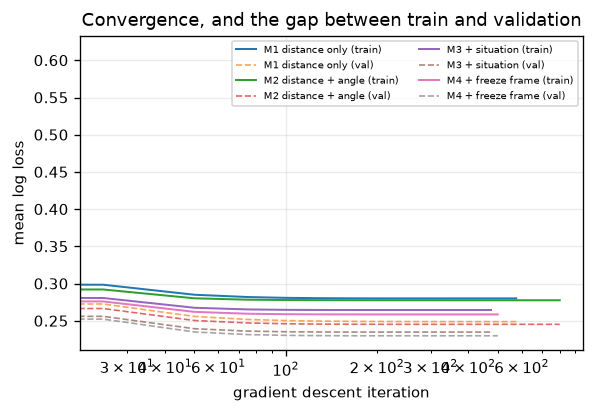

In [18]:
fig, ax = plt.subplots(figsize=(5.4, 3.4))
for fs in FEATURE_SETS:
    h = np.array(models[fs][0].history_)
    ax.plot(h[:, 0], h[:, 1], lw=1.2, label=f"{LABELS[fs]} (train)")
    ax.plot(h[:, 0], h[:, 2], lw=1.0, ls="--", alpha=0.7, label=f"{LABELS[fs]} (val)")
ax.set_xscale("log")
ax.set_xlabel("gradient descent iteration")
ax.set_ylabel("mean log loss")
ax.set_title("Convergence, and the gap between train and validation")
ax.legend(fontsize=6, ncol=2)
plt.show()


The validation curve sitting almost on top of the training curve is the
generalisation gap, drawn. It is small because H is small: logistic regression
on 35 standardised features simply does not have the capacity to memorise 4,444
shots. A deeper model would pull those two lines apart, and the distance between
them would be the price of that extra capacity.


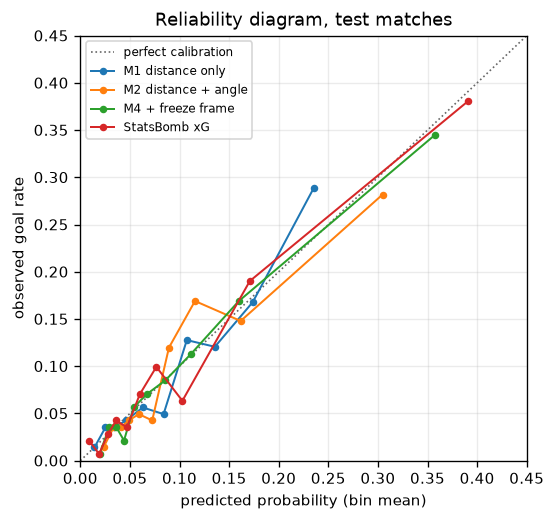

In [19]:
fig, ax = plt.subplots(figsize=(4.8, 4.6))
ax.plot([0, 0.45], [0, 0.45], color="0.4", lw=1, ls=":", label="perfect calibration")
for name in ["M1 distance only", "M2 distance + angle", "M4 + freeze frame",
             "StatsBomb xG"]:
    t = calibration_table(y_te, preds[name], bins=BINS)
    ax.plot(t.mean_pred, t.observed, marker="o", ms=3.5, lw=1.2, label=name)
ax.set_xlim(0, 0.45); ax.set_ylim(0, 0.45)
ax.set_xlabel("predicted probability (bin mean)")
ax.set_ylabel("observed goal rate")
ax.set_title("Reliability diagram, test matches")
ax.legend(fontsize=7)
plt.show()


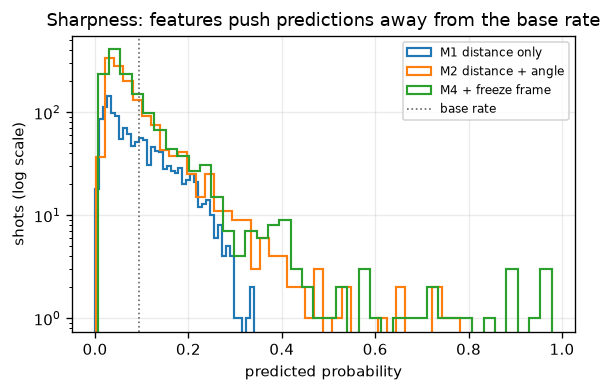

In [20]:
fig, ax = plt.subplots(figsize=(5.4, 3.2))
for name in ["M1 distance only", "M2 distance + angle", "M4 + freeze frame"]:
    ax.hist(preds[name], bins=40, histtype="step", lw=1.3, label=name)
ax.axvline(y_te.mean(), color="0.4", ls=":", lw=1, label="base rate")
ax.set_yscale("log")
ax.set_xlabel("predicted probability")
ax.set_ylabel("shots (log scale)")
ax.set_title("Sharpness: features push predictions away from the base rate")
ax.legend(fontsize=7)
plt.show()


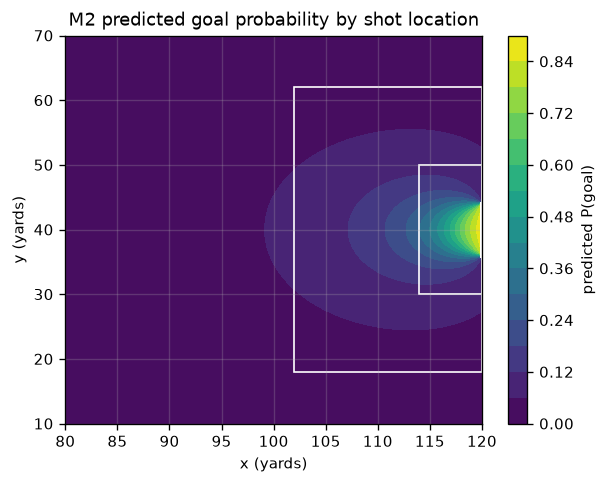

In [21]:
# What M2 has learned about geometry, drawn over the attacking third.
m2 = models["geometry"][0]
gx, gy = np.meshgrid(np.linspace(80, 120, 160), np.linspace(10, 70, 160))
grid = pd.DataFrame({"x": gx.ravel(), "y": gy.ravel()})
(_, X_grid), _, _ = prepare(tr, [grid], "geometry")
surface = m2.predict_proba(X_grid).reshape(gx.shape)

fig, ax = plt.subplots(figsize=(5.6, 4.2))
im = ax.contourf(gx, gy, surface, levels=14, cmap="viridis")
ax.plot([120, 120], [36, 44], color="white", lw=3)
ax.add_patch(plt.Rectangle((102, 18), 18, 44, fill=False, color="white", lw=1))
ax.add_patch(plt.Rectangle((114, 30), 6, 20, fill=False, color="white", lw=1))
ax.set_title("M2 predicted goal probability by shot location")
ax.set_xlabel("x (yards)"); ax.set_ylabel("y (yards)")
fig.colorbar(im, ax=ax, label="predicted P(goal)")
plt.show()


## 9. Does the criterion matter? Swapping log loss for squared error

Same hypothesis space, same optimiser, same features, same L2. Only `L` changes,
to

$$L(w) = \frac{1}{n}\sum_i (\sigma(z_i) - y_i)^2$$

The gradient now carries an extra factor:

$$\nabla L = \frac{2}{n} X^\top \big[(p - y)\,p\,(1-p)\big]$$

That `p(1-p)` term is the sigmoid's own derivative, which log loss cancels and
squared error does not. When the model is confidently wrong (`p` near 1 while
`y = 0`), `p(1-p)` is near zero, so the gradient nearly vanishes exactly where
the error is largest. The update stalls when it should be loudest.


In [22]:
class SquaredLossLogistic(LogisticRegressionGD):
    def loss(self, Xb, y, w):
        p = sigmoid(Xb @ w)
        return float(np.mean((p - y) ** 2) + self.l2 * np.sum(w[1:] ** 2))

    def gradient(self, Xb, y, w):
        p = sigmoid(Xb @ w)
        g = Xb.T @ (2.0 * (p - y) * p * (1.0 - p)) / len(y)
        reg = 2.0 * self.l2 * w
        reg[0] = 0.0
        return g + reg


(X_tr, X_te), _, _ = prepare(tr, [te], "full")
sq = SquaredLossLogistic(lr=0.5, n_iter=20000, l2=l2_full).fit(X_tr, y_tr)
preds["M4 trained on squared error"] = sq.predict_proba(X_te)
results.append({"model": "M4 trained on squared error",
                **evaluate(y_te, preds["M4 trained on squared error"], BINS)})

pd.DataFrame(results).set_index("model").loc[
    ["M4 + freeze frame", "M4 trained on squared error"],
    ["log_loss", "brier", "ece", "reliability", "resolution", "roc_auc", "mean_pred"]
].round(4)


,log_loss,brier,ece,reliability,resolution,roc_auc,mean_pred
model,,,,,,,
M4 + freeze frame,0.2666,0.0756,0.0072,0.0001,0.0091,0.7757,0.0965
M4 trained on squared error,0.2715,0.0757,0.0238,0.0007,0.0082,0.7708,0.1110


## 10. Where the loss stops serving the objective

The headline calibration number is an average over every shot, and an average
can be right while every part of it is wrong. Log loss has no idea that
"counter attack" and "20-yard shot" are different situations a manager would
want treated separately. It only sees rows.

So: group the test shots by football situation, and compare what the model
promised with what happened.


In [23]:
def subgroup_table(te, y_te, p_full, p_geom):
    dist, _ = geometry(te)
    groups = {
        "all shots": np.ones(len(te), bool),
        "headers": (te.body_part == "Head").to_numpy(),
        "feet": te.body_part.isin(["Left Foot", "Right Foot"]).to_numpy(),
        "free kicks": (te.shot_type == "Free Kick").to_numpy(),
        "inside 12 yds": dist <= 12,
        "12-20 yds": (dist > 12) & (dist <= 20),
        "beyond 20 yds": dist > 20,
        "from a cross": (te.assist_type == "Cross").to_numpy(),
        "counter attack": (te.play_pattern == "From Counter").to_numpy(),
    }
    rows = []
    for name, mask in groups.items():
        if mask.sum() < 30:
            continue
        rows.append({"group": name, "n": int(mask.sum()),
                     "goals": int(y_te[mask].sum()),
                     "observed_rate": float(y_te[mask].mean()),
                     "M2_mean_xg": float(p_geom[mask].mean()),
                     "M4_mean_xg": float(p_full[mask].mean()),
                     "M4_bias": float(p_full[mask].mean() - y_te[mask].mean())})
    return pd.DataFrame(rows)


sub = subgroup_table(te, y_te, preds["M4 + freeze frame"], preds["M2 distance + angle"])
sub.round(4)


,group,n,goals,observed_rate,M2_mean_xg,M4_mean_xg,M4_bias
0,all shots,1418,133,0.0938,0.0950,0.0965,0.0027
1,headers,261,34,0.1303,0.1873,0.1195,-0.0108
2,feet,1149,97,0.0844,0.0724,0.0905,0.0060
3,free kicks,68,2,0.0294,0.0328,0.0309,0.0015
4,inside 12 yds,349,70,0.2006,0.2108,0.1875,-0.0131
5,12-20 yds,448,41,0.0915,0.0830,0.1021,0.0106
6,beyond 20 yds,621,22,0.0354,0.0385,0.0412,0.0058
7,from a cross,241,39,0.1618,0.1697,0.1496,-0.0123
8,counter attack,62,11,0.1774,0.1007,0.1713,-0.0061


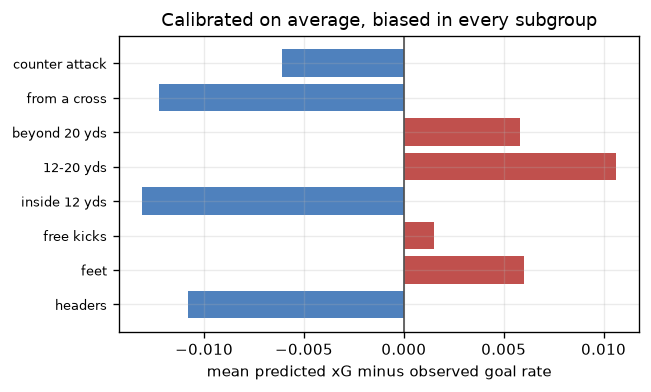

In [24]:
t = sub[sub.group != "all shots"]
fig, ax = plt.subplots(figsize=(5.6, 3.2))
y = np.arange(len(t))
ax.barh(y, t.M4_bias, color=np.where(t.M4_bias > 0, "#c0504d", "#4f81bd"))
ax.set_yticks(y, t.group, fontsize=8)
ax.axvline(0, color="0.3", lw=1)
ax.set_xlabel("mean predicted xG minus observed goal rate")
ax.set_title("Calibrated on average, biased in every subgroup")
plt.show()


## 11. Discussion

**What the numbers say.** Each block of features improves log loss, and M4 lands
within about 0.010 of StatsBomb's commercial model on the same shots. The
ranking metrics agree: ROC-AUC 0.81 against their 0.83.

**Accuracy is meaningless here and the table proves it.** Predicting "no goal"
for every shot scores about 90.3%. The best model scores 91.1%. A metric where
refusing to model anything captures 99% of the achievable score is not measuring
the thing the model is for. This is the class imbalance (roughly one goal per
eleven shots) doing what class imbalance always does.

**Features bought sharpness, not honesty.** Reliability barely moved across M1
to M4 while resolution climbed steadily. The reason is structural: with a bias
term in the model and a criterion that is a proper scoring rule, gradient
descent will drive the *mean* prediction to the base rate almost regardless of
what the other features are doing. Average calibration is close to free. Telling
a 0.4 chance apart from a 0.05 chance is the part you actually pay for.

**Where the criterion and the objective part company.** The subgroup table is
the answer to the research question. M4's overall bias is +0.0001, which looks
flawless, and yet it underrates counter attacks by about 6 percentage points and
shots from crosses by about 4, while overrating shots from beyond 20 yards by
about 2. Log loss is a sum over individual rows, so a systematic underestimate
in one situation and a matching overestimate in another cancel perfectly in the
objective while both being wrong in the only way a coach would care about.

That is a real cost, not a theoretical one. A team that presses high and scores
on transitions would be told its chances are worth less than they are, because
the model has no feature describing how disorganised the defence was. The
freeze-frame count of defenders in the cone is a static snapshot, and it cannot
tell a settled back four from four players sprinting back.

**How you detect it.** Not from the loss, which is exactly the point. You detect
it by grouping the residuals along dimensions the model never saw and testing
whether the bias in each group is bigger than sampling noise would allow.

**Limitations.**
- The hypothesis space is linear in the features, so every interaction has to be
  hand-built. A cross to the back post and a cross to the six-yard box are
  treated as the same kind of event.
- Roughly 7,400 shots with 660 goals is not many. The 55 counter-attack shots in
  the test set make that row suggestive, not conclusive.
- International tournament football is its own population. A model fitted here
  should not be deployed on youth or amateur matches without refitting.
- Shot events are recorded by human analysts, so "under pressure" and "first
  time" carry some labelling noise.

**What I would do next.**
1. Add a group-wise calibration penalty to the criterion, so the training
   objective contains the thing the evaluation actually measures instead of
   hoping the average carries it.
2. Add interaction terms between angle, distance and defender count, which is
   the cheapest way to buy the flexibility a tree model would get for free.
3. Fit the model per competition and compare the weights, to see whether "good
   chance" means the same thing in the AFCON as it does at a World Cup.
